In [1]:
import importlib
import logging
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

logging.basicConfig()
logging.getLogger().setLevel(logging.INFO)

from datetime import datetime
from portfolio_optimization import *
import numpy as np

# S&P and Dow Jones Tickers
sp_dj_asset_tickers = {
    "SPY": "U.S. Equities",                     # SPDR S&P 500 ETF Trust                     
    "SPDW": "International Equities",           # SPDR Portfolio Developed World ex-US ETF
    "SPEM": "Emerging Market Equities",         # SPDR Portfolio Emerging Markets ETF
    "RWX": "Real Estate",                       # SPDR Dow Jones International Real Estate ETF (RWX)
    "^SPGSCI": "Commodities",                     # Dow Jones Commodity Index
    "LQD": "Investment-Grade Bonds",            # S&P 500 Bond Index
    "SPHY": "High-Yield Bonds",                 # SPDR Portfolio High Yield Bond ETF
    "BWX": "International Sovereign Bonds"      # SPDR Bloomberg International Treasury Bond ETF
}

ishares_asset_tickers = {
     "LQD": "Investment-Grade Bonds",            # iShares iBoxx $ Investment Grade Corporate Bond ETF
     "IGOV": "International Sovereign Bonds",    # iShares International Treasury Bond ETF
     "HYG": "High-Yield Bonds",                  # iShares iBoxx $ High Yield Corporate Bond ETF
     "IVV": "U.S. Equities",                     # iShares Core S&P Total U.S. Stock Market ETF
     "EEM": "Emerging Market Equities",          # iShares MSCI Emerging Markets Index ETF
     "IXUS": "International Equities",           # iShares Core MSCI Total International Stock ETF (non-US)
     "IYR": "Real Estate",                       # iShares US Real Estate ETF (cannot find global older than 2008 crisis)
     "GSG": "Commodities"                        # iShares S&P GSCI Commodity-Indexed Trust
 } 

trading_days_in_year = 252
# Define the start and end dates for fetching the data
start_date = '2004-01-01'
end_date = datetime.today().strftime("%Y-%m-%d")

In [2]:
!pip install pandas yfinance matplotlib seaborn -q

In [3]:
tickers = dict(ishares_asset_tickers)

returns_df = download_tickers_returns(tickers=tickers, start_date=start_date) #, cache_path="../data/historical-asset-classes-returns-ishares.csv")
returns_df.tail()

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


,Investment-Grade Bonds,International Sovereign Bonds,High-Yield Bonds,U.S. Equities,Emerging Market Equities,International Equities,Real Estate,Commodities
Date,,,,,,,,
2024-08-14,0.004426,-0.000732,0.001786,0.003266,-0.005390,0.001620,0.003978,-0.003759
2024-08-15,-0.003058,-0.005864,0.000891,0.017117,0.011074,0.011471,-0.003024,0.005189
2024-08-16,0.002977,0.004424,0.003181,0.002266,0.011652,0.007124,0.000314,-0.007977
2024-08-19,0.002338,0.005628,0.001649,0.009293,0.009675,0.010972,0.007633,-0.006622
2024-08-20,0.002258,0.005839,-0.001963,-0.001475,-0.008556,-0.003998,-0.001764,-0.005000


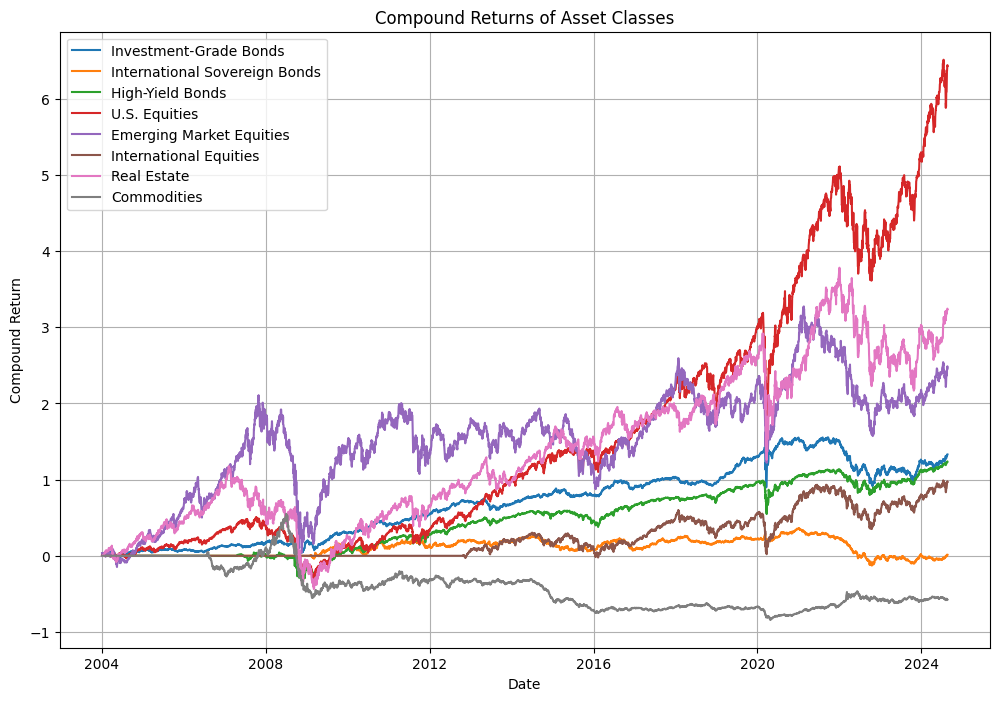

In [4]:
# Calculate compound returns
compound_returns = (1 + returns_df).cumprod() - 1

# Plot the compound returns
plt.figure(figsize=(12, 8))
for column in compound_returns.columns:
    plt.plot(compound_returns.index, compound_returns[column], label=column)

plt.title('Compound Returns of Asset Classes')
plt.ylabel('Compound Return')
plt.xlabel('Date')
plt.legend()
plt.grid(True)
plt.show()

differentiates between upside and downside volatility. The Sortino Ratio considers only downside volatility when assessing risk. Realize since Commodities down-trending, Omega penalizes more than Sharpe does, and since S&P / Emerging Markets up-trending, the former rewards it more than Sharpe does.


Annualized Statistics:
Mean: 0.054985
Standard Deviation: 0.122166
Variance: 0.014925
5th Percentile: -0.010830
95th Percentile: 0.010474


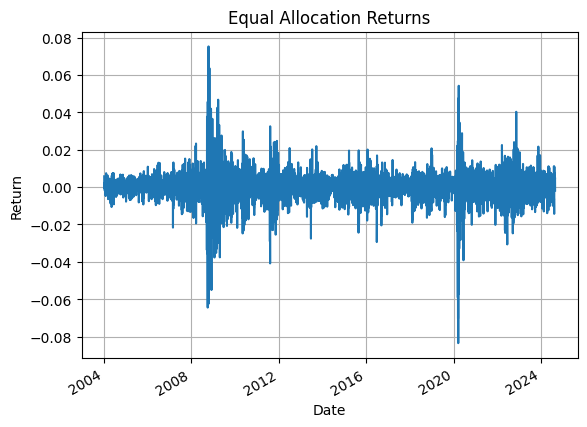

In [5]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

imported_module = importlib.import_module("portfolio_optimization")
importlib.reload(imported_module)
from portfolio_optimization import *


annualized_factor_from_freq = {'daily': 252}


def calculate_basic_stats(returns, frequency='daily'):
    annual_factor = annualized_factor_from_freq.get(frequency, 252)
    stats = {
        'Mean': returns.mean() * annual_factor,
        'Standard Deviation': returns.std() * np.sqrt(annual_factor),
        'Variance': returns.var() * annual_factor,
        '5th Percentile': returns.quantile(0.05),
        '95th Percentile': returns.quantile(0.95)
    }
    return stats

# Example portfolio weights
port_weights = len(returns_df.columns) * [1 / len(returns_df.columns)]
eq_alloc_returns = np.dot(returns_df, port_weights)
eq_alloc_returns = pd.Series(eq_alloc_returns, index=returns_df.index)

# Calculate statistics
stats = calculate_basic_stats(eq_alloc_returns)

print("\nAnnualized Statistics:")
for key, value in stats.items():
    print(f"{key}: {value:.6f}")

# Plot the returns
eq_alloc_returns.plot(title='Equal Allocation Returns')
plt.xlabel('Date')
plt.ylabel('Return')
plt.grid(True)
plt.show()


For Sortino, we're going to test thresholds of 
* 0%,understanding how well the portfolio performs against zero return
* 2%,considers a realistic risk-free rate
* 5% (average portfolio return annual equal contribution)

In [6]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

imported_module = importlib.import_module("portfolio_optimization")
importlib.reload(imported_module)
from portfolio_optimization import *

# Define annualized factor for daily frequency
annualized_factor_from_freq = {'daily': 252}

# # Returns 3 years prior
# last_date = returns_df.index[-1]
# start_date = last_date - pd.DateOffset(years=3)
# recent_returns_df = returns_df.loc[start_date:]

# Get mean returns and covariance matrix
expected_returns = annualized_expected_return(returns=returns_df)
vol_returns = returns_df.std() * np.sqrt(annualized_factor_from_freq['daily'])
cov_matrix = returns_df.cov() * annualized_factor_from_freq['daily']

# Define thresholds
thresholds = [0.0, 0.02, 0.05, 0.10]

# Calculate Sortino Ratio for each threshold
sortino_ratios = {}
for threshold in thresholds:
    sortino_ratios[f'Sortino Ratio (MAR={threshold:.0%})'] = sortino_ratio(returns=returns_df,threshold=threshold)

# Calculate Sharpe Ratio
sharpe_ratio_value = sharpe_ratio(expected_return=expected_returns, volatility_return=vol_returns, risk_free_rate=0.01)

# Create DataFrame for results
results = pd.DataFrame({
    'Sharpe Ratio': sharpe_ratio_value,
    **sortino_ratios
})

# Display results
print("Performance Metrics:")
results


Performance Metrics:


,Sharpe Ratio,Sortino Ratio (MAR=0%),Sortino Ratio (MAR=2%),Sortino Ratio (MAR=5%),Sortino Ratio (MAR=10%)
Investment-Grade Bonds,0.417701,0.591906,0.586876,0.579537,0.567829
International Sovereign Bonds,-0.086012,-0.121487,-0.120190,-0.118296,-0.115275
High-Yield Bonds,0.340459,0.490196,0.487215,0.482807,0.475634
U.S. Equities,0.596905,0.836331,0.833006,0.828151,0.820391
Emerging Market Equities,0.337126,0.485546,0.484106,0.482003,0.478643
International Equities,0.253661,0.346330,0.344676,0.342218,0.338191
Real Estate,0.377109,0.534722,0.533335,0.531306,0.528053
Commodities,-0.120674,-0.163421,-0.162850,-0.162016,-0.160682


## Compare performances

In [7]:
import importlib
imported_module = importlib.import_module("portfolio_optimization")
importlib.reload(imported_module)
from portfolio_optimization import *

obj_performances = pd.DataFrame(index=returns_df.index)
all_weights = {}

for ind, objective in zip(["Sharpe", "Sortino", "Omega"], [MaxSharpeRatio, MaxSortinoRatio, MaxOmegaRatio]):
    _, port_weights = calculate_historical_portfolio_allocation(
        returns=returns_df,
        objective_class=objective,
        frequency='daily',
        min_exposure=0.05,
        max_exposure=0.3
    )
    port_returns = compute_weighted_returns(weights=port_weights, returns=returns_df)
    
    obj_performances[ind] = port_returns
    all_weights[ind] = port_weights.iloc[-1]

weights_df = pd.DataFrame(all_weights).T

# plot compound returns
plot_portfolio_performance(obj_performances)


/home/alan/Quantropy/env/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:434: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
/home/alan/Quantropy/env/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:438: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)
/home/alan/Quantropy/env/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:492: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  a_eq = vstack([con['jac'](x, *con['args'])
/home/alan/Quantropy/env/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:498: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  a_ieq = vstack([con['jac'](x, *con['args'])
/home/alan/Quantropy/env/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:434: RuntimeWarning: Values in x were outside bounds durin

ZeroDivisionError: float division by zero

In [35]:
import importlib
imported_module = importlib.import_module("portfolio_optimization")
importlib.reload(imported_module)
from portfolio_optimization import *

(1 + convert_annual_threshold_to_frequency(0.02, frequency))**252

1.0199999999999838

In [30]:
weights_df.T

,Sharpe,Sortino,Omega
Investment-Grade Bonds,0.05,0.050000,0.05
International Sovereign Bonds,0.05,0.050000,0.05
High-Yield Bonds,0.15,0.116156,0.15
U.S. Equities,0.30,0.300000,0.30
Emerging Market Equities,0.05,0.050000,0.05
International Equities,0.05,0.083844,0.05
Real Estate,0.05,0.050000,0.05
Commodities,0.30,0.300000,0.30


In [15]:
portfolio_performance(portfolio_returns=sharpe_portfolio_returns, frequency="daily")

,inception,1Y,3Y,5Y,10Y
annualized_return,0.064904,0.124317,0.012434,0.054208,0.055371
annualized_volatility,0.099767,0.079064,0.105855,0.107149,0.085497
sharpe_ratio,0.550325,1.445878,0.022996,0.412585,0.530673


In [16]:
portfolio_performance(portfolio_returns=eq_portfolio_returns, frequency="daily")

NameError: name 'eq_portfolio_returns' is not defined

## Compare latest-suggested weights

In [ ]:
# Plot each objective's performance
fig, ax = plt.subplots(figsize=(12, 6))

bar_width = 0.2
index = range(len(obj_performances.columns))

for i, objective in enumerate(["Sharpe", "Sortino", "Omega"]):
    ax.bar(index[i], obj_performances[objective].mean(), bar_width, label=objective)
    # Add text annotation for the latest weight recommendation
    weight_str = ', '.join([f"{weight:.2f}" for weight in weights_df.loc[objective]])
    ax.text(index[i], obj_performances[objective].mean(), weight_str, ha='center', va='bottom')

ax.set_xticks(index)
ax.set_xticklabels(["Sharpe", "Sortino", "Omega"])
ax.set_ylabel('Performance')
ax.set_title('Objective Performance and Latest Weight Recommendations')
ax.legend()

plt.show()

We developed better definitions of what conssitutes "risk" and "reward". We will go even more into "reward" in the Smart Beta notebook when explaining how else we can compute expected returns. We still have robust covariance to cover in this notebook.